## Triplet Loss

Triplet Loss — это один из лоссов для contrastive learning. Чтобы учить модель с помощью этого лосса, модели не нужен последний классификационный слой. Этот лосс работает прямо с эмбеддингами $x_i$ элементов, которые выдает модель.

Снова скажем, что идея лосса — заставить эмбеддинги лиц одного человека быть более близкими по некоторому расстоянию, а эмбеддинги лиц разных людей — далекими друг от друга. Общая формула лосса выглядит так:

$$L(e, p, n) = max\{d(a, p) - d(a, n) + margin, 0\},$$

здесь
- $e$ — эмбеддинг входного лица (output модели)
- $p$ — "positive" эмбеддинг для входного лица (т.е. эмбеддинг такого элемента, что мы хотим, чтобы $e$ и $p$ были близки. В нашем случае это значит, что $e$ и $p$ должны быть выходами сети на два разных фото одного и того же человека).
- $n$ — "negative" эмбеддинг для входного лица (т.е. эмбеддинг такого элемента, что мы хотим, чтобы $e$ и $p$ были далеки. В нашем случае это значит, что $e$ и $p$ должны быть выходами сети на два разных фото разных людей).
- $d(x, y)$ — метрика расстояния между эмбеддингами, по которой мы их сравниваем.
- margin — гиперпараметр, который заставляет $d(a, p)$ и $d(a, n)$ быть еще дальше друг от друга.

**Эмбеддинги $e$, $p$ и $n$ нужно нормализовать, прежде чем подавать в лосс-функцию**.

У TripletLoss есть куча разных вариаций. В некоторых из них больше гиперпараметров, в других предлагают использовать больше одного позитивного и негативного эмбеддинга за раз. Где-то предлагается умный способ выбора negative эмбеддинга (например, выбирается такой, на котором нейросеть пока плохо работает, т.е. считает $e$ и $n$ близкими).

Пример реализации TripletLoss можно найти [здесь](https://pytorch.org/docs/stable/generated/torch.nn.TripletMarginWithDistanceLoss.html#torch.nn.TripletMarginWithDistanceLoss).

Будьте готовы, что TripletLoss придется настраивать, чтобы добиться хорошего результата при обучении сети.


**Что нужно учесть при реализации Triplet Loss**:
- при обучении мы обычно хотим следить за ходом обучения модели, считая какую-то метрику качества. Тут у нас больше нет классификационного слоя, так что accuracy мы считать не можем. Нужно придумать, как в случае Triplet Loss считать метрику качества на вализации в течение обучения. Подумайте, как можно это сделать?
- скорее всего, чтобы обучить сеть на Triplet Loss, придется написать кастомный Dalaset/Dataloader, который будет возвращать тройки элементов (anchor, positive, negative).
- не забудьте нормализовать эмбеддинги перед подсчетом лосса! Это можно сделать руками, а можно, например, добавить в конец сети batchnorm без обучаемых параметров.

**Доп литература по Triplet Loss**:

- Идея TripletLoss: https://en.wikipedia.org/wiki/Triplet_loss
- Хорошая статья про batch mining techniques для выбора positive и negative элементов: https://omoindrot.github.io/triplet-loss#triplet-mining


## Импорты

In [1]:
from google.colab import drive

import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision.models as models
import torchvision.transforms as T

from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil

from tqdm import tqdm
import matplotlib.pyplot as plt


## Загрузка датасета

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Пути
DATA_PATH = '/content/drive/MyDrive/DLS1'
IDENTITY_FILE = os.path.join(DATA_PATH, 'person_id_aligned.csv')
IMAGES_DIR = os.path.join(DATA_PATH, 'aligned_images')

# Локальные папки для обработки
RAW_DIR = '/content/dataset/raw'          # Копии изображений
TRAIN_DIR = '/content/dataset/train'
VAL_DIR = '/content/dataset/val'

# Создаём папки
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

In [4]:
# Читаем файл
df = pd.read_csv(IDENTITY_FILE)

# Если первая колонка действительно не нужна, убираем её
if 'Unnamed: 0.1' in df.columns:
    df = df.drop(columns=['Unnamed: 0.1'])

# Проверяем оставшиеся колонки
# print("Колонки в df:", df.columns.tolist())
df.head()

,Unnamed: 0,image_id,person_id
0,0,000001.jpg,2880
1,14,000015.jpg,1854
2,15,000016.jpg,4905
3,17,000018.jpg,2464
4,33,000034.jpg,1603


In [5]:
import zipfile
ARCHIVE_PATH = os.path.join(DATA_PATH, 'aligned_images.zip')  # путь к архиву

# Распаковка архива
print("Распаковываю архив...")
with zipfile.ZipFile(ARCHIVE_PATH, 'r') as zip_ref:
    zip_ref.extractall(RAW_DIR)
print(f"Архив распакован в: {RAW_DIR}")

Распаковываю архив...
Архив распакован в: /content/dataset/raw


In [6]:
src = '/content/dataset/raw/content/drive/MyDrive/DLS1/aligned_images'
dst = '/content/dataset/raw'

# Копируем всё содержимое (файлы и папки)
for item in os.listdir(src):
    shutil.move(os.path.join(src, item), os.path.join(dst, item))

In [7]:
missing = []
for _, row in df.iterrows():
    filepath = os.path.join(RAW_DIR, row['image_id'])
    if not os.path.exists(filepath):
        missing.append(row['image_id'])

# Результат
print(f"\nВсего файлов в CSV: {len(df)}")
print(f"Не найдено в папке: {len(missing)}")


Всего файлов в CSV: 16686
Не найдено в папке: 0


In [8]:
# оставляем только файлы, которые реально есть в RAW_DIR
df['file_exists'] = df['image_id'].apply(
    lambda x: os.path.exists(os.path.join(RAW_DIR, x))
)
df_filtered = df[df['file_exists']].reset_index(drop=True)

print(f"Всего файлов в исходном CSV: {len(df)}")
print(f"Файлы найдены: {len(df_filtered)}")
print(f"Отсутствуют: {len(df) - len(df_filtered)}\n")

# Статистика по персонам
person_counts = df_filtered['person_id'].value_counts().sort_index()  # кол-во фото на персону

n_persons = len(person_counts)
min_images = person_counts.min()
max_images = person_counts.max()
mean_images = person_counts.mean()
median_images = person_counts.median()

print("--- Статистика по персонам ---")
print(f"Количество персон (person_id): {n_persons}")
print(f"Минимальное количество фото на персону: {min_images}")
print(f"Максимальное количество фото на персону: {max_images}")
print(f"Среднее количество фото на персону: {mean_images:.2f}")
print(f"Медиана количества фото на персону: {median_images:.1f}\n")

Всего файлов в исходном CSV: 16686
Файлы найдены: 16686
Отсутствуют: 0

--- Статистика по персонам ---
Количество персон (person_id): 556
Минимальное количество фото на персону: 30
Максимальное количество фото на персону: 35
Среднее количество фото на персону: 30.01
Медиана количества фото на персону: 30.0



Все отлично, все скопировалось. Теперь нужно раскидать датасет на train/val
У нас по 30 картинок на персону, но функцию лучше напистаь универсальную, вдруг потом пересоберем датасет. Пищшем с учетом, если есть по 1 картинке на персону.

In [9]:
grouped = df_filtered.groupby('person_id')['image_id'].apply(list)

train_count = 0
val_count = 0

for person_id, image_list in grouped.items():
    # Для каждой персоны отдельно делим изображения
    if len(image_list) == 1:
        # Если 1 изображение — только в train
        train_images = image_list
        val_images = []
    else:
        # 80% в train, 20% в val
        train_images, val_images = train_test_split(
            image_list, test_size=0.2, random_state=42
        )

    # Создаём папки для персоны
    train_person_dir = os.path.join(TRAIN_DIR, f'person_{person_id}')
    val_person_dir = os.path.join(VAL_DIR, f'person_{person_id}')
    os.makedirs(train_person_dir, exist_ok=True)
    os.makedirs(val_person_dir, exist_ok=True)

    # Копируем файлы
    for img in train_images:
        src = os.path.join(RAW_DIR, img)
        dst = os.path.join(train_person_dir, img)
        shutil.copy2(src, dst)
        train_count += 1

    for img in val_images:
        src = os.path.join(RAW_DIR, img)
        dst = os.path.join(val_person_dir, img)
        shutil.copy2(src, dst)
        val_count += 1

# Итог
print("--- Результат ---")
print(f"Всего изображений в train: {train_count}")
print(f"Всего изображений в val: {val_count}")
print(f"Количество персон в train: {len(os.listdir(TRAIN_DIR))}")
print(f"Количество персон в val: {len(os.listdir(VAL_DIR))}")

--- Результат ---
Всего изображений в train: 13348
Всего изображений в val: 3338
Количество персон в train: 556
Количество персон в val: 556


Отлично поделилось, переходим к нейросети.

## Реализация  TripletLoss

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Нужно создать датасет с учетом использования триплет (описание в начале ноутбука)

In [11]:
class TripletFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, num_triplets_per_class=100):
        self.root_dir = root_dir
        self.transform = transform
        self.num_triplets_per_class = num_triplets_per_class


        # Собираем классы и пути к изображениям
        self.class_to_paths = {}
        class_names = sorted(os.listdir(root_dir))
        for class_name in class_names:
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_paths[class_name] = [
                    os.path.join(class_path, img_name)
                    for img_name in os.listdir(class_path)
                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
                ]

        self.classes = list(self.class_to_paths.keys())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}


    def __len__(self):
        return len(self.classes) * self.num_triplets_per_class


    def __getitem__(self, idx):
        # Выбираем класс для anchor/positive
        class_idx = idx // self.num_triplets_per_class
        class_name = self.classes[class_idx]


        # Берём два разных изображения из этого класса (anchor и positive)
        paths = self.class_to_paths[class_name]
        if len(paths) < 2:
            # Если в классе <2 изображений — дублируем
            anchor_path = paths[0]
            positive_path = paths[0]
        else:
            anchor_path, positive_path = random.sample(paths, 2)


        # Выбираем класс для negative (другой класс)
        other_classes = [c for c in self.classes if c != class_name]
        neg_class = random.choice(other_classes)
        neg_path = random.choice(self.class_to_paths[neg_class])


        # Загружаем изображения
        anchor = Image.open(anchor_path).convert('RGB')
        positive = Image.open(positive_path).convert('RGB')
        negative = Image.open(neg_path).convert('RGB')


        # Применяем трансформации
        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)


        return anchor, positive, negative

Пишем класс для Триплет Лосс

In [12]:
class TripletLoss(nn.Module):
    def __init__(self, margin=0.2):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        # Нормализуем эмбеддинги (L2)
        anchor = F.normalize(anchor, p=2, dim=1)
        positive = F.normalize(positive, p=2, dim=1)
        negative = F.normalize(negative, p=2, dim=1)


        # Расстояния: d(a,p) и d(a,n)
        d_apos = F.pairwise_distance(anchor, positive, p=2)
        daneg = F.pairwise_distance(anchor, negative, p=2)


        # Triplet Loss: max(d(a,p) − d(a,n) + margin, 0)
        loss = torch.relu(d_apos - daneg + self.margin)
        return loss.mean()


Теперь класс основной нейросети Resnet с учетом, что классификатор нам не нужен, а нужен только последний слой с эмбеддингами:

In [13]:
class ResNet50Embedding(nn.Module):
    def __init__(self, embedding_size=512):
        super().__init__()
        self.resnet = models.resnet50(pretrained=True)
        # Заменяем fc на полносвязный слой для эмбеддингов
        self.fc = nn.Linear(self.resnet.fc.in_features, embedding_size)
        self.resnet.fc = nn.Identity()  # Удаляем исходный fc


    def forward(self, x):
        x = self.resnet(x)
        x = self.fc(x)
        return x  # [B, embedding_size]

Трансформации картинок, даталоадеры:

In [14]:
# Трансформации
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Датасеты
train_dataset = TripletFaceDataset('/content/dataset/train', transform=train_transform, num_triplets_per_class=100)
val_dataset = TripletFaceDataset('/content/dataset/val', transform=val_transform, num_triplets_per_class=50)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

Функция обучения модели:

In [15]:
# Модель и loss
model = ResNet50Embedding(embedding_size=512).to(device)
criterion = TripletLoss(margin=0.2)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for anchor, positive, negative in tqdm(loader, desc="Train"):
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

        optimizer.zero_grad()


        a_emb = model(anchor)
        p_emb = model(positive)
        n_emb = model(negative)


        loss = criterion(a_emb, p_emb, n_emb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * anchor.size(0)
    return running_loss / len(loader.dataset)
def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_triplets = 0  # Считаем, сколько троек удовлетворяют d(a,p) < d(a,n)
    total_triplets = 0

    with torch.no_grad():
        for anchor, positive, negative in tqdm(loader, desc="Val"):
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            # Получаем эмбеддинги
            a_emb = model(anchor)
            p_emb = model(positive)
            n_emb = model(negative)

            # Вычисляем loss (для мониторинга)
            loss = criterion(a_emb, p_emb, n_emb)
            running_loss += loss.item() * anchor.size(0)

            # Нормализуем эмбеддинги
            a_emb = F.normalize(a_emb, p=2, dim=1)
            p_emb = F.normalize(p_emb, p=2, dim=1)
            n_emb = F.normalize(n_emb, p=2, dim=1)

            # Считаем расстояния
            d_apos = F.pairwise_distance(a_emb, p_emb, p=2)  # d(a, p)
            daneg = F.pairwise_distance(a_emb, n_emb, p=2)  # d(a, n)

            # Проверяем условие: d(a,p) < d(a,n)
            # Если верно — тройка «корректна» (модель хорошо разделяет классы)
            correct = (d_apos < daneg).sum().item()
            correct_triplets += correct
            total_triplets += anchor.size(0)


    # Средние значения
    avg_loss = running_loss / len(loader.dataset)
    accuracy = correct_triplets / total_triplets if total_triplets > 0 else 0.0

    return avg_loss, accuracy

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 123MB/s]


Здесь функция сохранения (для дообучения в дальнейшем, а то уж очень медленная модель с триплет лосс):

In [ ]:
import json
from datetime import datetime

def save_model(
    model,
    optimizer,
    epoch,
    train_loss,
    val_loss,
    val_acc,
    save_dir="checkpoints",
    model_name="triplet_resnet50"
):
    """
    Сохраняет:
    - state_dict модели
    - state_dict оптимизатора (для возобновления обучения)
    - метаданные (epoch, метрики)
    """
    # Создаём директорию
    os.makedirs(save_dir, exist_ok=True)

    # Имя файла с датой и эпохой
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    checkpoint_name = f"{model_name}_epoch_{epoch}_{timestamp}.pth"
    checkpoint_path = os.path.join(save_dir, checkpoint_name)

    metadata_path = os.path.join(save_dir, f"{model_name}_metadata.json")

    # Составляем словарь для сохранения
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'model_config': {
            'embedding_size': model.fc.out_features,
            'margin': criterion.margin  # если criterion глобальный
        }
    }

    # Сохраняем чекпоинт
    torch.save(checkpoint, checkpoint_path)
    print(f"Модель сохранена: {checkpoint_path}")

    # Сохраняем метаданные отдельно (удобно для анализа)
    with open(metadata_path, 'w') as f:
        json.dump({
            'last_saved': timestamp,
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc
        }, f, indent=2)
    print(f"Метаданные сохранены: {metadata_path}")

Запускаем обучение:

In [21]:
# Списки для накопления метрик
train_losses = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = val_epoch(model, val_loader, criterion, device)
    scheduler.step()

    # Сохраняем метрики
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet_triplet.pth")
        #save_model(model, optimizer, epoch, train_loss, val_loss, val_acc, save_dir=save_dir, model_name=f"{model_name}_best") # раскомментировать, если нужно созхранять всю модель целиком,включая архитектуру (не нужно в данном случае)
        print(f"Сохранена лучшая модель (Val Acc: {val_acc:.4f})")


Val: 100%|██████████| 869/869 [04:50<00:00,  2.99it/s]


Epoch 1: Train Loss: 0.0235, Val Loss: 0.0265, Val Acc: 0.9461
Сохранена лучшая модель (Val Acc: 0.9461)


Val: 100%|██████████| 869/869 [04:51<00:00,  2.98it/s]


Epoch 2: Train Loss: 0.0184, Val Loss: 0.0243, Val Acc: 0.9513
Сохранена лучшая модель (Val Acc: 0.9513)


Val: 100%|██████████| 869/869 [04:49<00:00,  3.00it/s]


Epoch 3: Train Loss: 0.0146, Val Loss: 0.0211, Val Acc: 0.9592
Сохранена лучшая модель (Val Acc: 0.9592)


Val: 100%|██████████| 869/869 [05:02<00:00,  2.87it/s]


Epoch 4: Train Loss: 0.0121, Val Loss: 0.0206, Val Acc: 0.9589


Val: 100%|██████████| 869/869 [04:49<00:00,  3.00it/s]


Epoch 5: Train Loss: 0.0103, Val Loss: 0.0201, Val Acc: 0.9604
Сохранена лучшая модель (Val Acc: 0.9604)


Сохраняем модельку:

In [22]:
model_path = '/content/resnet_triplet.pth'
drive_path = '/content/drive/MyDrive/DLS1/resnet_triplet.pth'
# Копируем файлы
!cp "{model_path}" "{drive_path}"
# Список файлов в корне Drive
!ls "/content/drive/MyDrive/DLS1/"

aligned_images	    landmarks_cropped.csv  resnet_ce.pth
aligned_images.zip  person_id_aligned.csv  resnet_triplet_3epoch.pth
attrs.csv	    person_id.csv	   resnet_triplet.pth
celeba_cropped.zip  resnet_arcface.pth	   stacked_hourglass.pth


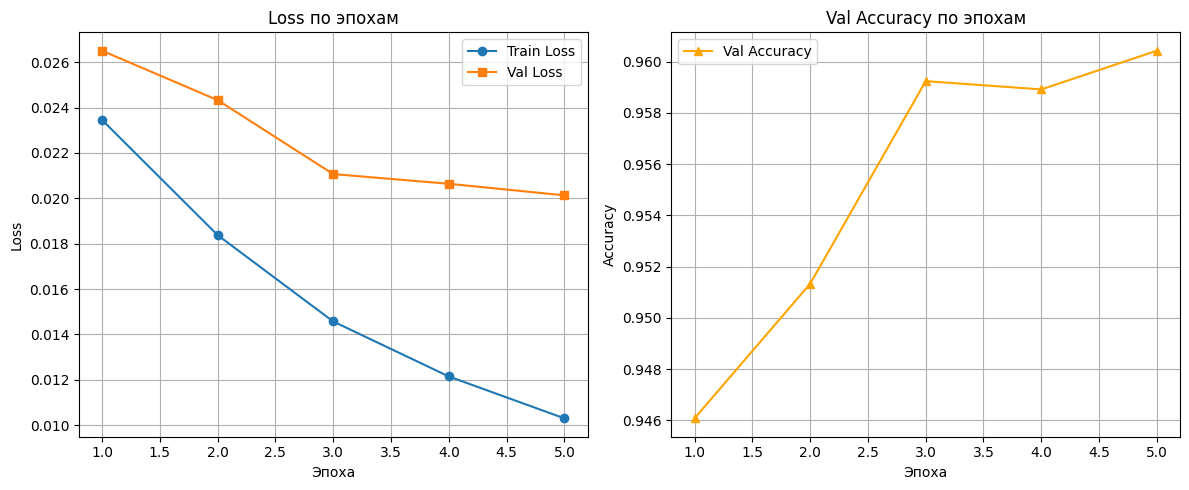

In [23]:
# Визуализация после обучения
plt.figure(figsize=(12, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss', marker='s')
plt.title('Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), val_accuracies, label='Val Accuracy', marker='^', color='orange')
plt.title('Val Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Закомментирован код для доучивания модели:

In [ ]:
'''
def load_model(checkpoint_path, model, optimizer=None, device='cpu'):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


    print(f!Модель загружена из {checkpoint_path}")
    print(f"Эпоха: {checkpoint['epoch']}")
    print(f!Val Acc: {checkpoint['val_acc']:.4f}")

    return model, optimizer, checkpoint['epoch']

# Пример загрузки
model = ResNet50Embedding(embedding_size=512)  # ваша архитектура
model.to(device)

model, _, _ = load_model("checkpoints/triplet_resnet50_best.pth", model, device=device)
model.eval()  # для инференса
'''

TODO:
1. Посчитать с метрикой `Triplet Accuracy` с маржой:
`d(anchor, positive) + margin < d(anchor, negative)`
будет
2. Попробовать доучить на 10 эпохах и посмотреть, что будет.

**Внимание, дальнейший код написан, но обучение не проведено до конца, поскольку не хватило времени.**

При этом, модель второй эпохи сохранена, и можно посмотреть на ее работу в пайплайне.

Напишем код для метрики `Triplet Accuracy` с маржой:
`d(anchor, positive) + margin < d(anchor, negative)`
будет

In [24]:
def compute_triplet_accuracy(anchor_emb, positive_emb, negative_emb, margin=0.2):
    """
    Считает долю триплетов, для которых выполняется:
        d(anchor, positive) + margin < d(anchor, negative)

    Args:
        anchor_emb: тензор [B, D] — эмбеддинги anchor
        positive_emb: тензор [B, D] — эмбеддинги positive
        negative_emb: тензор [B, D] — эмбеддинги negative
        margin: скаляр — значение маржи из TripletLoss


    Returns:
        accuracy: float — доля триплетов, удовлетворяющих неравенству
    """
    # L2-расстояние между anchor и positive
    d_apos = torch.pairwise_distance(anchor_emb, positive_emb, p=2)  # [B]

    # L2-расстояние между anchor и negative
    d_aneg = torch.pairwise_distance(anchor_emb, negative_emb, p=2)  # [B]


    # Проверяем условие: d(a,p) + margin < d(a,n)
    correct = (d_apos + margin) < d_aneg  # [B], bool
    accuracy = correct.float().mean().item()  # доля True

    return accuracy

Поменяем функцию `val_epoch`, интегрировав в нее новую `Triplet_accuracy`

In [25]:
def val_epoch(model, loader, criterion, device, margin=0.2):
    model.eval()
    running_loss = 0.0
    total_triplets = 0
    correct_triplets = 0  # счётчик триплетов, где условие выполняется

    with torch.no_grad():
        for anchor, positive, negative in tqdm(loader, desc="Val"):
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            # Получаем эмбеддинги
            a_emb = model(anchor)
            p_emb = model(positive)
            n_emb = model(negative)

            # Вычисляем loss (для мониторинга)
            loss = criterion(a_emb, p_emb, n_emb)
            running_loss += loss.item() * anchor.size(0)

            # Нормализуем эмбеддинги (если модель требует)
            a_emb = F.normalize(a_emb, p=2, dim=1)
            p_emb = F.normalize(p_emb, p=2, dim=1)
            n_emb = F.normalize(n_emb, p=2, dim=1)


            # Считаем Triplet Accuracy
            acc = compute_triplet_accuracy(a_emb, p_emb, n_emb, margin=margin)
            correct_triplets += acc * anchor.size(0)  # взвешиваем на размер батча
            total_triplets += anchor.size(0)

    # Средние значения
    avg_loss = running_loss / len(loader.dataset)
    triplet_acc = correct_triplets / total_triplets if total_triplets > 0 else 0.0

    return avg_loss, triplet_acc

Можно обучаться:

In [ ]:
# Списки для накопления метрик
train_losses = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

num_epochs = 4
margin = 0.2  # значение маржи из TripletLoss

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = val_epoch(model, val_loader, criterion, device, margin=margin)
    scheduler.step()

    # Сохраняем метрики
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet_triplet_2.pth")
        print(f"Сохранена лучшая модель (Val Acc: {val_acc:.4f})")

Val: 100%|██████████| 869/869 [04:48<00:00,  3.01it/s]


Epoch 1: Train Loss: 0.0094, Val Loss: 0.0196, Val Acc: 0.8860
Сохранена лучшая модель (Val Acc: 0.8860)


Val: 100%|██████████| 869/869 [04:47<00:00,  3.02it/s]


Epoch 2: Train Loss: 0.0081, Val Loss: 0.0198, Val Acc: 0.8896
Сохранена лучшая модель (Val Acc: 0.8896)


Val:  25%|██▌       | 221/869 [01:15<03:35,  3.01it/s]

In [ ]:
model_path = '/content/resnet_triplet_2.pth'
drive_path = '/content/drive/MyDrive/DLS1/resnet_triplet_2.pth'
# Копируем файлы
!cp "{model_path}" "{drive_path}"
# Список файлов в корне Drive
!ls "/content/drive/MyDrive/DLS1/"

In [ ]:
# Визуализация после обучения
plt.figure(figsize=(12, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss', marker='s')
plt.title('Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), val_accuracies, label='Val Accuracy', marker='^', color='orange')
plt.title('Val Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()